# Create Fine-Grained Hierarchical Dataset

This notebook creates a **fine-grained hierarchical** brain region dataset.

This is the finest granularity level:
- Coarse: 17 categories ("frontal lobe") - max 65.5% frequency
- Intermediate: 69 categories ("superior frontal gyrus") - max 19.2% frequency  
- **Fine: ~100-150 categories ("left superior frontal gyrus") - target <15% max frequency**

Strategy: Further split high-frequency intermediate terms by:
- Laterality (left/right for all major regions)
- Subregions (angular/supramarginal for IPL, BA subdivisions for PFC)
- Functional areas (V1/V2/V3 for visual, rostral/dorsal/subgenual for ACC)

**Note**: This dataset can also be generated by running the `merge_cogatlas_ngrams.py` script with appropriate parameters. The script has been updated to load all data files from HuggingFace automatically.

In [1]:
import sys
sys.path.append('../../')

from neurovlm.brain_region_hierarchy_fine import (
    merge_cogatlas_with_fine_regions,
    save_fine_hierarchical_dataset,
    BRAIN_REGION_HIERARCHY_FINE
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
# Load CogAtlas data
cogatlas_matrix = np.load("cogatlas_term_matrix.npy")
cogatlas_labels = np.load("cogatlas_term_labels.npy", allow_pickle=True).tolist()
cogatlas_pmids = np.load("cogatlas_term_pmids.npy")

print(f"CogAtlas data:")
print(f"  Shape: {cogatlas_matrix.shape}")
print(f"  Terms: {len(cogatlas_labels)}")
print(f"  PMIDs: {len(cogatlas_pmids)}")

CogAtlas data:
  Shape: (29868, 808)
  Terms: 808
  PMIDs: 29868


In [3]:
# Load merged complete data (CogAtlas + all brain regions)
merged_matrix = np.load("merged_complete_term_matrix.npy")
merged_labels = np.load("merged_complete_term_labels.npy", allow_pickle=True).tolist()

print(f"\nMerged complete data:")
print(f"  Shape: {merged_matrix.shape}")
print(f"  Terms: {len(merged_labels)}")

# Separate brain regions (everything after CogAtlas terms)
n_cogatlas = len(cogatlas_labels)
brain_region_matrix = merged_matrix[:, n_cogatlas:]
brain_region_labels = merged_labels[n_cogatlas:]

print(f"\nBrain region data (extracted):")
print(f"  Shape: {brain_region_matrix.shape}")
print(f"  Terms: {len(brain_region_labels)}")


Merged complete data:
  Shape: (29868, 1519)
  Terms: 1519

Brain region data (extracted):
  Shape: (29868, 711)
  Terms: 711


## Preview Fine Hierarchy

Show examples of the fine-grained categories:

In [4]:
print("Sample fine-grained categories:\n")
print(f"Total fine categories: {len(BRAIN_REGION_HIERARCHY_FINE)}\n")

# Show some examples of splits
examples = [
    "left superior frontal gyrus",
    "right superior frontal gyrus",
    "left angular gyrus",
    "right supramarginal gyrus",
    "left anterior insula",
    "right posterior insula",
    "left primary visual cortex",
    "left inferior temporal gyrus"
]

for parent in examples:
    if parent in BRAIN_REGION_HIERARCHY_FINE:
        children = BRAIN_REGION_HIERARCHY_FINE[parent]
        print(f"{parent}:")
        print(f"  → {', '.join(children[:5])}{'...' if len(children) > 5 else ''}")
        print(f"  ({len(children)} child terms)\n")

Sample fine-grained categories:

Total fine categories: 129

left superior frontal gyrus:
  → left superior frontal, left superior frontal gyrus, left sfg, l superior frontal, l sfg
  (5 child terms)

right superior frontal gyrus:
  → right superior frontal, right superior frontal gyrus, right sfg, r superior frontal, r sfg
  (5 child terms)

left angular gyrus:
  → left angular, left angular gyrus, left ba39, l angular
  (4 child terms)

right supramarginal gyrus:
  → right supramarginal, right supramarginal gyrus, right ba40, r supramarginal
  (4 child terms)

left anterior insula:
  → left anterior insula, left anterior insular, l anterior insula, lai
  (4 child terms)

right posterior insula:
  → right posterior insula, right posterior insular, r posterior insula, rpi
  (4 child terms)

left primary visual cortex:
  → left primary visual, left v1, left ba17, left striate, left calcarine...
  (7 child terms)

left inferior temporal gyrus:
  → left inferior temporal, left itg, left b

## Create Fine Hierarchical Dataset

In [5]:
# Create fine hierarchical dataset
fine_matrix, fine_labels, merge_info = merge_cogatlas_with_fine_regions(
    cogatlas_matrix,
    cogatlas_labels,
    brain_region_matrix,
    brain_region_labels,
    min_papers_per_parent=5
)

print("\n" + "="*70)
print("Fine Hierarchical Dataset Created")
print("="*70)
print(f"\nShape: {fine_matrix.shape}")
print(f"Total terms: {len(fine_labels)}")
print(f"  - CogAtlas terms: {merge_info['n_cogatlas_terms']}")
print(f"  - Fine brain regions: {merge_info['n_collapsed_brain_regions']}")
print(f"\nReduction: {merge_info['n_original_brain_regions']} → {merge_info['n_collapsed_brain_regions']} brain region terms")
print(f"\nComparison:")
print(f"  - Coarse hierarchy: 17 brain regions")
print(f"  - Intermediate hierarchy: 69 brain regions")
print(f"  - Fine hierarchy: {merge_info['n_collapsed_brain_regions']} brain regions")


Collapsing 711 terms to hierarchical regions...
  Matched 173 terms to parent regions
  Unmatched: 538 terms
  Created 90 parent regions (min 5 papers)
  Sparsity reduction: 98.72% → 96.66%
  Papers per parent: mean=998.0, std=1280.0, min=83, max=5730

Fine Hierarchical Dataset Created

Shape: (29868, 898)
Total terms: 898
  - CogAtlas terms: 808
  - Fine brain regions: 90

Reduction: 711 → 90 brain region terms

Comparison:
  - Coarse hierarchy: 17 brain regions
  - Intermediate hierarchy: 69 brain regions
  - Fine hierarchy: 90 brain regions


## Analyze Class Balance

In [6]:
# Calculate term frequencies
n_cogatlas = merge_info['n_cogatlas_terms']

# Fine brain region terms
fine_brain_labels = fine_labels[n_cogatlas:]
fine_brain_matrix = fine_matrix[:, n_cogatlas:]

term_freqs = []
for i, term in enumerate(fine_brain_labels):
    count = fine_brain_matrix[:, i].sum()
    freq = count / len(fine_matrix)
    term_freqs.append((term, count, freq))

term_freqs.sort(key=lambda x: x[1], reverse=True)

print("=== Top 25 Most Frequent Fine Brain Region Terms ===")
print(f"{'Term':<50s} {'Count':>8s} {'Frequency':>10s}")
print("-" * 70)
for term, count, freq in term_freqs[:25]:
    print(f"{term:<50s} {count:8d} {freq*100:9.1f}%")

print(f"\n=== Distribution Statistics ===")
counts = [x[1] for x in term_freqs]
print(f"Max frequency: {max(counts)/len(fine_matrix)*100:.1f}%")
print(f"Mean count: {np.mean(counts):.1f}")
print(f"Median count: {np.median(counts):.1f}")
print(f"\nCompare to:")
print(f"  - Coarse hierarchy: max 65.5% (frontal lobe)")
print(f"  - Intermediate hierarchy: max 19.2% (left primary visual cortex)")
print(f"  - Fine hierarchy: max {max(counts)/len(fine_matrix)*100:.1f}%")

=== Top 25 Most Frequent Fine Brain Region Terms ===
Term                                                  Count  Frequency
----------------------------------------------------------------------
left primary visual cortex                             5730      19.2%
left superior frontal gyrus                            5715      19.1%
left premotor cortex                                   5473      18.3%
right anterior cingulate cortex                        4542      15.2%
left anterior insula                                   4463      14.9%
left inferior parietal lobule                          3818      12.8%
dorsal anterior cingulate cortex                       3212      10.8%
left precuneus                                         3007      10.1%
left inferior frontal gyrus                            2952       9.9%
left posterior cingulate cortex                        2578       8.6%
left frontal pole                                      2536       8.5%
left caudate nucleus    

## Visualize Frequency Distribution

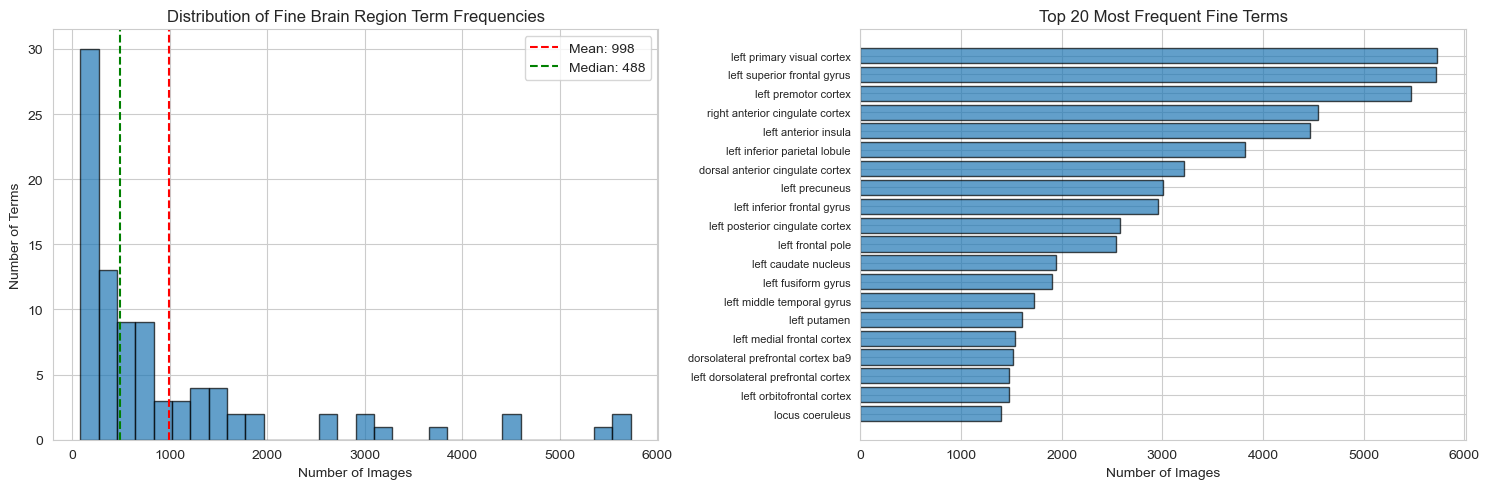

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of term frequencies
counts = [x[1] for x in term_freqs]
axes[0].hist(counts, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Images')
axes[0].set_ylabel('Number of Terms')
axes[0].set_title('Distribution of Fine Brain Region Term Frequencies')
axes[0].axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
axes[0].axvline(np.median(counts), color='green', linestyle='--', label=f'Median: {np.median(counts):.0f}')
axes[0].legend()

# Top 20 terms
top_20 = term_freqs[:20]
terms_short = [t[0][:40] for t in top_20]  # Truncate long names
counts_top = [t[1] for t in top_20]

axes[1].barh(range(len(top_20)), counts_top, alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(top_20)))
axes[1].set_yticklabels(terms_short, fontsize=8)
axes[1].set_xlabel('Number of Images')
axes[1].set_title('Top 20 Most Frequent Fine Terms')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Compare All Hierarchies

In [8]:
comparison_df = pd.DataFrame([
    {
        'Dataset': 'CogAtlas Only',
        'Total Terms': len(cogatlas_labels),
        'Brain Region Terms': 0,
        'Max Frequency': f"{cogatlas_matrix.sum(axis=0).max() / len(cogatlas_matrix) * 100:.1f}%"
    },
    {
        'Dataset': 'Merged Complete',
        'Total Terms': len(merged_labels),
        'Brain Region Terms': len(brain_region_labels),
        'Max Frequency': f"{merged_matrix[:, n_cogatlas:].sum(axis=0).max() / len(merged_matrix) * 100:.1f}%"
    },
    {
        'Dataset': 'Coarse Hierarchical',
        'Total Terms': 825,
        'Brain Region Terms': 17,
        'Max Frequency': '65.5%'
    },
    {
        'Dataset': 'Intermediate Hierarchical',
        'Total Terms': 877,
        'Brain Region Terms': 69,
        'Max Frequency': '19.2%'
    },
    {
        'Dataset': 'Fine Hierarchical',
        'Total Terms': len(fine_labels),
        'Brain Region Terms': merge_info['n_collapsed_brain_regions'],
        'Max Frequency': f"{max(counts) / len(fine_matrix) * 100:.1f}%"
    }
])

print("\n" + "="*70)
print("Dataset Comparison")
print("="*70)
print(comparison_df.to_string(index=False))


Dataset Comparison
                  Dataset  Total Terms  Brain Region Terms Max Frequency
            CogAtlas Only          808                   0          9.9%
          Merged Complete         1519                 711         21.2%
      Coarse Hierarchical          825                  17         65.5%
Intermediate Hierarchical          877                  69         19.2%
        Fine Hierarchical          898                  90         19.2%


## Check Specific High-Frequency Terms from Intermediate

See how the problematic high-frequency terms were split:

In [9]:
# Terms that were high in intermediate hierarchy
problematic_terms = [
    "left primary visual cortex",
    "primary motor cortex", 
    "posterior insula",
    "superior frontal gyrus",
    "right anterior cingulate cortex",
    "left anterior insula",
    "posterior cingulate cortex",
    "inferior parietal lobule",
    "inferior temporal gyrus"
]

print("How high-frequency intermediate terms were split in fine hierarchy:\n")
for term in problematic_terms:
    # Find all fine terms that contain this term
    related_fine = [(t, c, f) for t, c, f in term_freqs if term.lower() in t.lower() or t.lower() in term.lower()]
    
    if related_fine:
        print(f"\n{term}:")
        for fine_term, count, freq in related_fine[:5]:  # Top 5 related
            print(f"  → {fine_term}: {count} ({freq*100:.1f}%)")
    else:
        # Check if term exists as-is
        exact_match = [(t, c, f) for t, c, f in term_freqs if t.lower() == term.lower()]
        if exact_match:
            t, c, f = exact_match[0]
            print(f"\n{term}: {c} ({f*100:.1f}%) [not split]")

How high-frequency intermediate terms were split in fine hierarchy:


left primary visual cortex:
  → left primary visual cortex: 5730 (19.2%)

primary motor cortex:
  → left primary motor cortex: 1168 (3.9%)
  → right primary motor cortex: 267 (0.9%)

posterior insula:
  → left posterior insula: 386 (1.3%)

superior frontal gyrus:
  → left superior frontal gyrus: 5715 (19.1%)
  → right superior frontal gyrus: 308 (1.0%)

right anterior cingulate cortex:
  → right anterior cingulate cortex: 4542 (15.2%)

left anterior insula:
  → left anterior insula: 4463 (14.9%)

posterior cingulate cortex:
  → left posterior cingulate cortex: 2578 (8.6%)
  → right posterior cingulate cortex: 969 (3.2%)

inferior parietal lobule:
  → left inferior parietal lobule: 3818 (12.8%)
  → right inferior parietal lobule: 366 (1.2%)

inferior temporal gyrus:
  → right inferior temporal gyrus: 1367 (4.6%)
  → left inferior temporal gyrus: 221 (0.7%)


## Save Dataset

In [10]:
# Save fine hierarchical dataset
save_fine_hierarchical_dataset(
    fine_matrix,
    fine_labels,
    cogatlas_pmids,
    merge_info,
    output_prefix="fine_hierarchical_term"
)

print("\nSaved files:")
print("  - fine_hierarchical_term_matrix.npy")
print("  - fine_hierarchical_term_labels.npy")
print("  - fine_hierarchical_term_pmids.npy")
print("  - fine_hierarchical_term_merge_info.json")


Saved fine hierarchical dataset:
  fine_hierarchical_term_matrix.npy
  fine_hierarchical_term_labels.npy
  fine_hierarchical_term_pmids.npy
  fine_hierarchical_term_merge_info.json

Saved files:
  - fine_hierarchical_term_matrix.npy
  - fine_hierarchical_term_labels.npy
  - fine_hierarchical_term_pmids.npy
  - fine_hierarchical_term_merge_info.json
